<a href="https://colab.research.google.com/github/Silviya-Grace/TASK_05_Ecommerce_Return_Rate_Investigation-/blob/main/ecomerce_return_rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving ecommerce_returns_synthetic_data.csv to ecommerce_returns_synthetic_data.csv


In [3]:
import pandas as pd
df=pd.read_csv("ecommerce_returns_synthetic_data.csv")
df.to_string()

'         Order_ID    Product_ID       User_ID  Order_Date Return_Date Product_Category  Product_Price  Order_Quantity     Return_Reason Return_Status  Days_to_Return  User_Age User_Gender User_Location Payment_Method Shipping_Method  Discount_Applied\n0     ORD00000000  PROD00000000  USER00000000  2023-08-05  2024-08-26         Clothing         411.59               3      Changed mind      Returned           387.0        58        Male        City54     Debit Card        Next-Day             45.27\n1     ORD00000001  PROD00000001  USER00000001  2023-10-09  2023-11-09            Books         288.88               3        Wrong item      Returned            31.0        68      Female        City85    Credit Card         Express             47.79\n2     ORD00000002  PROD00000002  USER00000002  2023-05-06         NaN             Toys         390.03               5               NaN  Not Returned             NaN        22      Female        City30     Debit Card        Next-Day           

In [6]:
df.head(7)

,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,Days_to_Return,User_Age,User_Gender,User_Location,Payment_Method,Shipping_Method,Discount_Applied
0,ORD00000000,PROD00000000,USER00000000,2023-08-05,2024-08-26,Clothing,411.59,3,Changed mind,Returned,387.0,58,Male,City54,Debit Card,Next-Day,45.27
1,ORD00000001,PROD00000001,USER00000001,2023-10-09,2023-11-09,Books,288.88,3,Wrong item,Returned,31.0,68,Female,City85,Credit Card,Express,47.79
2,ORD00000002,PROD00000002,USER00000002,2023-05-06,NaN,Toys,390.03,5,NaN,Not Returned,NaN,22,Female,City30,Debit Card,Next-Day,26.64
3,ORD00000003,PROD00000003,USER00000003,2024-08-29,NaN,Toys,401.09,3,NaN,Not Returned,NaN,40,Male,City95,PayPal,Next-Day,15.37
4,ORD00000004,PROD00000004,USER00000004,2023-01-16,NaN,Books,110.09,4,NaN,Not Returned,NaN,34,Female,City80,Gift Card,Standard,16.37
5,ORD00000005,PROD00000005,USER00000005,2024-02-14,2024-09-22,Electronics,252.12,1,Defective,Returned,221.0,46,Female,City47,Debit Card,Next-Day,47.61
6,ORD00000006,PROD00000006,USER00000006,2023-05-29,2023-08-03,Clothing,382.89,2,Wrong item,Returned,66.0,25,Male,City50,Credit Card,Express,28.49


In [9]:
df.shape

(10000, 17)

In [5]:
df.tail()

,Order_ID,Product_ID,User_ID,Order_Date,Return_Date,Product_Category,Product_Price,Order_Quantity,Return_Reason,Return_Status,Days_to_Return,User_Age,User_Gender,User_Location,Payment_Method,Shipping_Method,Discount_Applied
9995,ORD00009995,PROD00009995,USER00009995,2023-10-20,NaN,Home,142.50,4,NaN,Not Returned,NaN,37,Male,City40,PayPal,Standard,34.27
9996,ORD00009996,PROD00009996,USER00009996,2023-02-25,NaN,Electronics,484.63,3,NaN,Not Returned,NaN,69,Male,City62,Debit Card,Express,25.44
9997,ORD00009997,PROD00009997,USER00009997,2024-05-10,NaN,Toys,386.57,5,NaN,Not Returned,NaN,46,Male,City74,Credit Card,Next-Day,12.67
9998,ORD00009998,PROD00009998,USER00009998,2024-02-13,NaN,Toys,129.22,1,NaN,Not Returned,NaN,34,Female,City34,Gift Card,Express,49.97
9999,ORD00009999,PROD00009999,USER00009999,2024-12-08,2024-09-09,Toys,459.42,5,Not as described,Returned,-90.0,24,Female,City51,Debit Card,Express,16.05


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Product_ID        10000 non-null  object 
 2   User_ID           10000 non-null  object 
 3   Order_Date        10000 non-null  object 
 4   Return_Date       5052 non-null   object 
 5   Product_Category  10000 non-null  object 
 6   Product_Price     10000 non-null  float64
 7   Order_Quantity    10000 non-null  int64  
 8   Return_Reason     5052 non-null   object 
 9   Return_Status     10000 non-null  object 
 10  Days_to_Return    5052 non-null   float64
 11  User_Age          10000 non-null  int64  
 12  User_Gender       10000 non-null  object 
 13  User_Location     10000 non-null  object 
 14  Payment_Method    10000 non-null  object 
 15  Shipping_Method   10000 non-null  object 
 16  Discount_Applied  10000 non-null  float64

In [18]:
df.isnull().sum()

,0
Order_ID,0
Product_ID,0
User_ID,0
Order_Date,0
Return_Date,0
Product_Category,0
Product_Price,0
Order_Quantity,0
Return_Reason,0
Return_Status,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [19]:
df[['Return_Date','Return_Reason','Days_to_Return']].fillna(0)

,Return_Date,Return_Reason,Days_to_Return
0,2024-08-26,Changed mind,387.0
1,2023-11-09,Wrong item,31.0
2,0,0,0.0
3,0,0,0.0
4,0,0,0.0
...,...,...,...
9995,0,0,0.0
9996,0,0,0.0
9997,0,0,0.0
9998,0,0,0.0


In [27]:
total_order=len(df)
return_order=(df['Return_Status']=='Returned').sum()
return_percentage=(total_order/return_order)*100
#print(return_percentage)
print(round(return_percentage,2),'%')

197.94 %


In [45]:
print(df['Order_Quantity'].agg(['mean','median','sum']))

print((df['User_Age']==25).sum())

mean          3.0061
median        3.0000
sum       30061.0000
Name: Order_Quantity, dtype: float64
174


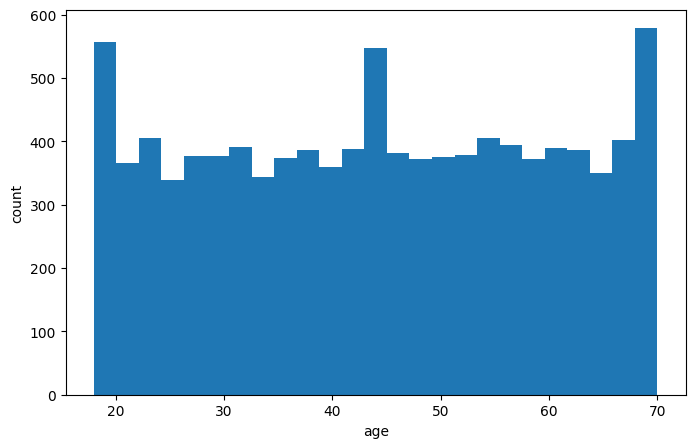

In [47]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['User_Age'],bins=25)
plt.xlabel("age")
plt.ylabel("count")
plt.show()


Return Rate by Category:
Product_Category
Books          50.661440
Clothing       52.450000
Electronics    50.931990
Home           49.014778
Toys           49.537037
Name: Return_Status, dtype: float64


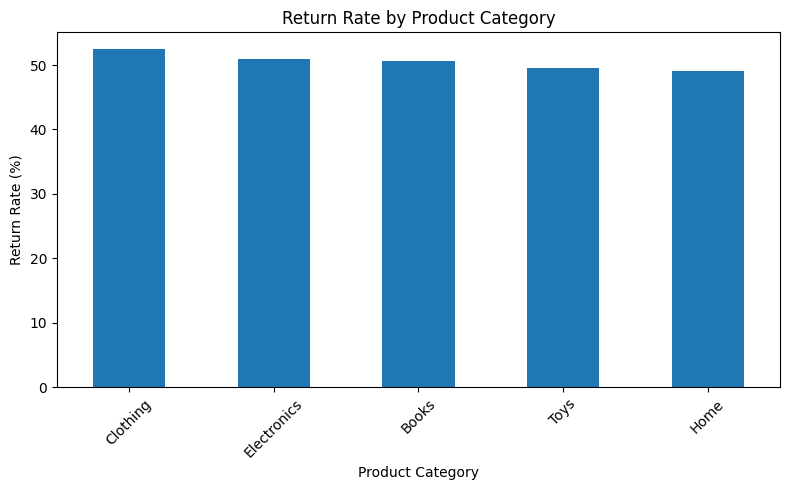

In [57]:
# Phase 3: Category vs Return Rate

category_return = (
    df.groupby('Product_Category')['Return_Status']
    .apply(lambda x: (x == 'Returned').mean() * 100)
)

print("\nReturn Rate by Category:")
print(category_return)

plt.figure(figsize=(8,5))
category_return.sort_values(ascending=False).plot(kind='bar')
plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Payment_Method
Credit Card    50.505459
Debit Card     51.115538
Gift Card      51.596374
PayPal         48.830645
Name: Returned, dtype: float64


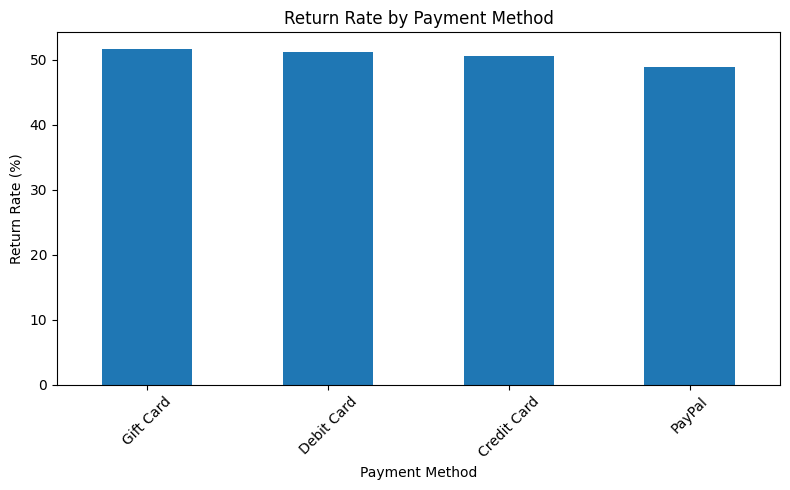

In [59]:
# Create numeric return column
df['Returned'] = (df['Return_Status'] == 'Returned').astype(int)

# Payment Method vs Return Rate
payment_return = (
    df.groupby('Payment_Method')['Returned']
    .mean() * 100
)

print(payment_return)

plt.figure(figsize=(8,5))
payment_return.sort_values(ascending=False).plot(kind='bar')
plt.title("Return Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

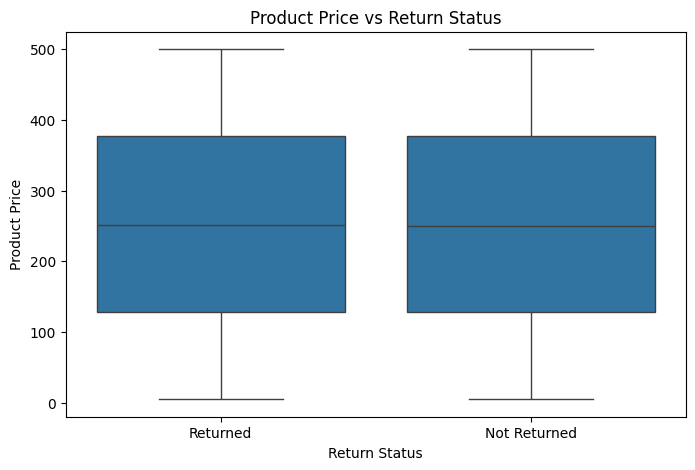

In [62]:
import seaborn as sns
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Return_Status',
    y='Product_Price',
    data=df
)

plt.title("Product Price vs Return Status")
plt.xlabel("Return Status")
plt.ylabel("Product Price")
plt.show()

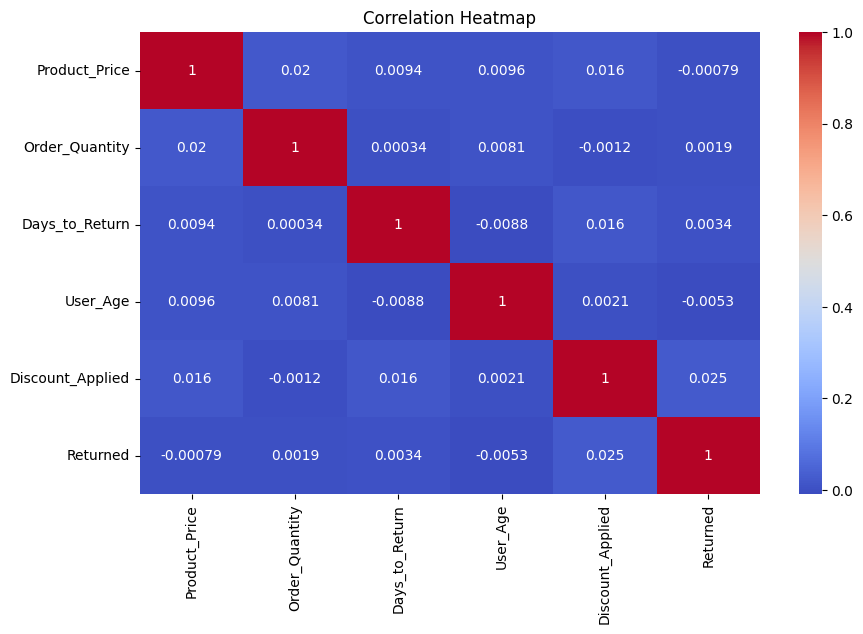

In [64]:
import numpy as np
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()


Number of Price Outliers: 0
Empty DataFrame
Columns: [Product_ID, Product_Category, Product_Price]
Index: []


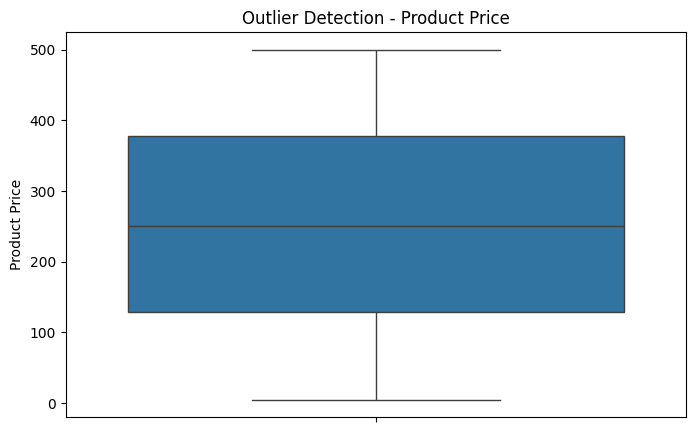

In [65]:
# Phase 4: Outlier Detection using IQR Method

Q1 = df['Product_Price'].quantile(0.25)
Q3 = df['Product_Price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Product_Price'] < lower_bound) |
    (df['Product_Price'] > upper_bound)
]

print("\nNumber of Price Outliers:", len(outliers))
print(outliers[['Product_ID', 'Product_Category', 'Product_Price']])

plt.figure(figsize=(8,5))
sns.boxplot(y=df['Product_Price'])
plt.title("Outlier Detection - Product Price")
plt.ylabel("Product Price")
plt.show()

In [66]:
from scipy.stats import chi2_contingency

# Contingency Table
contingency_table = pd.crosstab(
    df['Product_Category'],
    df['Return_Status']
)

print(contingency_table)

# Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Test Results")
print("Chi2 Statistic:", chi2)
print("P-value:", p)
print("Degrees of Freedom:", dof)

if p < 0.05:
    print("\nReject H0")
    print("Product Category significantly affects Return Status")
else:
    print("\nFail to Reject H0")
    print("No significant relationship found")

Return_Status     Not Returned  Returned
Product_Category                        
Books                     1007      1034
Clothing                   951      1049
Electronics                974      1011
Home                      1035       995
Toys                       981       963

Chi-Square Test Results
Chi2 Statistic: 5.722713373320355
P-value: 0.22083530275193664
Degrees of Freedom: 4

Fail to Reject H0
No significant relationship found


In [69]:
# Create Returned column
df['Returned'] = (
    df['Return_Status'] == 'Returned'
).astype(int)

# Calculate order value
df['Order_Value'] = (
    df['Product_Price'] *
    df['Order_Quantity']
)
#high return customer
customer_returns = (
    df.groupby('User_ID')['Returned']
    .sum()
)

high_return_customers = customer_returns[
    customer_returns >= 2
]

print("\nHigh Return Customers:")
print(high_return_customers.head())
#premium customer
customer_spending = (
    df.groupby('User_ID')['Order_Value']
    .sum()
)

premium_customers = customer_spending[
    customer_spending >
    customer_spending.quantile(0.75)
]

print(
    "\nPremium Customers Count:",
    len(premium_customers)
)


High Return Customers:
Series([], Name: Returned, dtype: int64)

Premium Customers Count: 2500


In [71]:
df['Returned'] = (
    df['Return_Status'] == 'Returned'
).astype(int)
print("\nOPERATIONS RECOMMENDATIONS")

# Highest return category
category_return = (
    df.groupby('Product_Category')['Returned']
    .mean() * 100
)

highest_category = category_return.idxmax()

# High return customers
high_return_customers = (
    df.groupby('User_ID')['Returned']
    .sum()
)

high_return_count = len(
    high_return_customers[
        high_return_customers >= 2
    ]
)

print(
    f"1. Focus on reducing returns in the '{highest_category}' category."
)

print(
    "2. Strengthen product quality checks before shipping."
)

print(
    "3. Improve product descriptions and images to set accurate expectations."
)

print(
    f"4. Monitor {high_return_count} customers with frequent returns."
)

print(
    "5. Review inventory planning for products with high return rates."
)

print(
    "6. Analyze return patterns regularly and take corrective actions."
)

print(
    "7. Provide better customer support to reduce avoidable returns."
)


OPERATIONS RECOMMENDATIONS
1. Focus on reducing returns in the 'Clothing' category.
2. Strengthen product quality checks before shipping.
3. Improve product descriptions and images to set accurate expectations.
4. Monitor 0 customers with frequent returns.
5. Review inventory planning for products with high return rates.
6. Analyze return patterns regularly and take corrective actions.
7. Provide better customer support to reduce avoidable returns.


In [72]:
# Return Rate by Payment Method

payment_return = (
    df.groupby('Payment_Method')['Returned']
    .mean() * 100
)

print("\nReturn Rate by Payment Method:")
print(payment_return)

# Highest Return Payment Method
highest_payment_method = payment_return.idxmax()
highest_return_rate = payment_return.max()

print(
    f"\nPayment Method with Highest Return Rate: {highest_payment_method}"
)

print(
    f"Return Rate: {highest_return_rate:.2f}%"
)


Return Rate by Payment Method:
Payment_Method
Credit Card    50.505459
Debit Card     51.115538
Gift Card      51.596374
PayPal         48.830645
Name: Returned, dtype: float64

Payment Method with Highest Return Rate: Gift Card
Return Rate: 51.60%


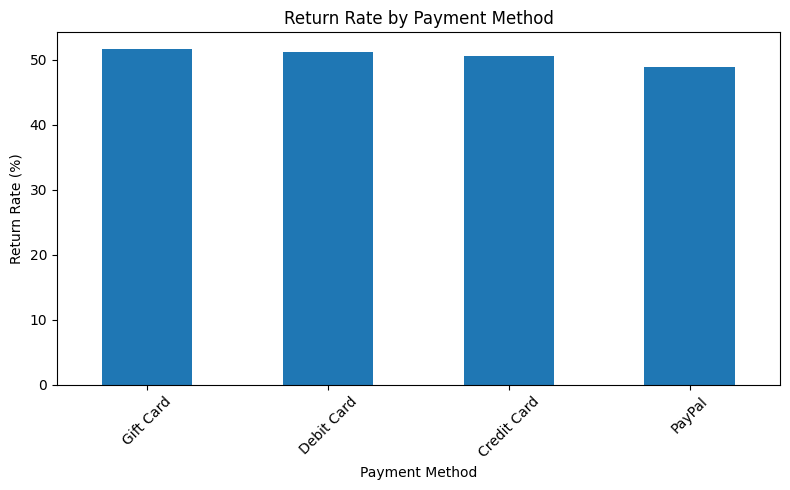

In [73]:
plt.figure(figsize=(8,5))

payment_return.sort_values(
    ascending=False
).plot(kind='bar')

plt.title('Return Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()